In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import sys
from pathlib import Path

# Add project root so we can import from src/
sys.path.append(str(Path.cwd().parent))

from src.processing.quant_logic import apply_no_vig_probabilities

df_raw = pd.read_csv('../data/raw/nba_2008-2025.csv')

print("Shape:", df_raw.shape)
print("\nColumns:", df_raw.columns.tolist())
df_raw.head()

Shape: (23118, 27)

Columns: ['season', 'date', 'regular', 'playoffs', 'away', 'home', 'score_away', 'score_home', 'q1_away', 'q2_away', 'q3_away', 'q4_away', 'ot_away', 'q1_home', 'q2_home', 'q3_home', 'q4_home', 'ot_home', 'whos_favored', 'spread', 'total', 'moneyline_away', 'moneyline_home', 'h2_spread', 'h2_total', 'id_spread', 'id_total']


,season,date,regular,playoffs,away,home,score_away,score_home,q1_away,q2_away,...,ot_home,whos_favored,spread,total,moneyline_away,moneyline_home,h2_spread,h2_total,id_spread,id_total
0,2008,2007-10-30,True,False,por,sa,97,106,26,23,...,0,home,13.0,189.5,900.0,-1400.0,5.0,95.0,0.0,1
1,2008,2007-10-30,True,False,utah,gs,117,96,28,34,...,0,home,1.0,212.0,100.0,-120.0,3.0,105.5,0.0,1
2,2008,2007-10-30,True,False,hou,lal,95,93,16,27,...,0,away,5.0,199.0,-230.0,190.0,3.0,99.0,0.0,0
3,2008,2007-10-31,True,False,phi,tor,97,106,22,28,...,0,home,6.5,191.0,255.0,-305.0,2.0,96.5,1.0,1
4,2008,2007-10-31,True,False,wsh,ind,110,119,23,22,...,16,away,1.5,203.5,-125.0,105.0,1.0,105.0,0.0,1


In [32]:
print("Null counts per column:")
print(df_raw.isnull().sum())

Null counts per column:
season               0
date                 0
regular              0
playoffs             0
away                 0
home                 0
score_away           0
score_home           0
q1_away              0
q2_away              0
q3_away              0
q4_away              0
ot_away              0
q1_home              0
q2_home              0
q3_home              0
q4_home              0
ot_home              0
whos_favored         0
spread               3
total                0
moneyline_away    3298
moneyline_home    3298
h2_spread         3296
h2_total          3301
id_spread            3
id_total             0
dtype: int64


In [33]:
clean_raw = df_raw.dropna(subset=['moneyline_away', 'moneyline_home']).copy()
print("Total games:", len(df_raw))
print("Games with valid moneylines:", len(clean_raw))
print("Games dropped due to missing moneylines:", len(df_raw) - len(clean_raw))
print(f"That's {((len(df_raw) - len(clean_raw)) / len(df_raw)) * 100:.1f}% of the data dropped")

Total games: 23118
Games with valid moneylines: 19820
Games dropped due to missing moneylines: 3298
That's 14.3% of the data dropped


In [34]:
# Rename columns to match what apply_no_vig_probabilities expects
clean_raw = clean_raw.rename(columns={
    'moneyline_home': 'home_odds',
    'moneyline_away': 'away_odds',
})

# Use the production no-vig function (includes NaN/zero-odds handling)
clean_raw = apply_no_vig_probabilities(clean_raw)

# Vig = overround - 1
avg_vig = (clean_raw['sportsbook_overround'] - 1).mean() * 100
print(f"Average sportsbook vig: {avg_vig:.2f}%")
print(f"Min vig: {(clean_raw['sportsbook_overround'] - 1).min() * 100:.2f}%")
print(f"Max vig: {(clean_raw['sportsbook_overround'] - 1).max() * 100:.2f}%")

Average sportsbook vig: 3.77%
Min vig: -3.92%
Max vig: 73.33%


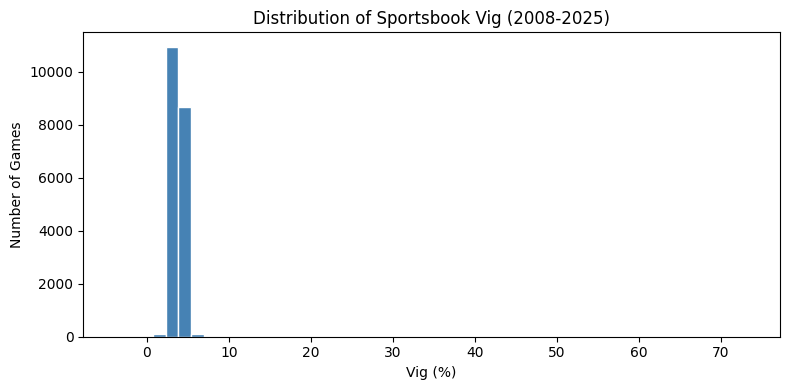

In [35]:
plt.figure(figsize=(8,4))
plt.hist((clean_raw['sportsbook_overround'] - 1) * 100, bins=50, color='steelblue', edgecolor='white')
plt.xlabel('Vig (%)')
plt.ylabel('Number of Games')
plt.title('Distribution of Sportsbook Vig (2008-2025)')
plt.tight_layout()
plt.show()

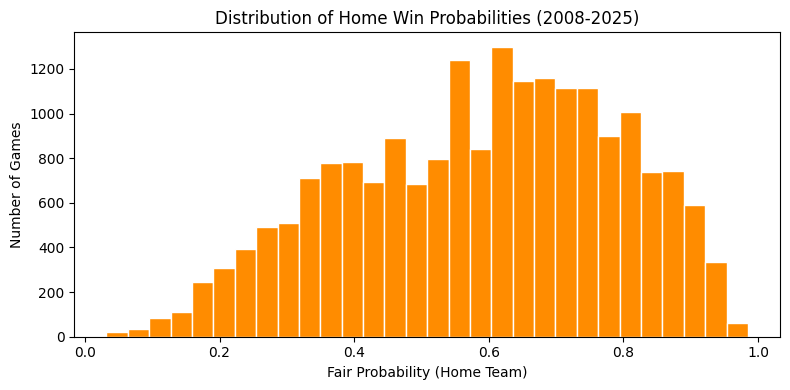

In [36]:
# fair_prob_home is already computed by apply_no_vig_probabilities in cell 4
plt.figure(figsize=(8,4))
plt.hist(clean_raw['fair_prob_home'], bins=30, color='darkorange', edgecolor='white')
plt.xlabel('Fair Probability (Home Team)')
plt.ylabel('Number of Games')
plt.title('Distribution of Home Win Probabilities (2008-2025)')
plt.tight_layout()
plt.show()

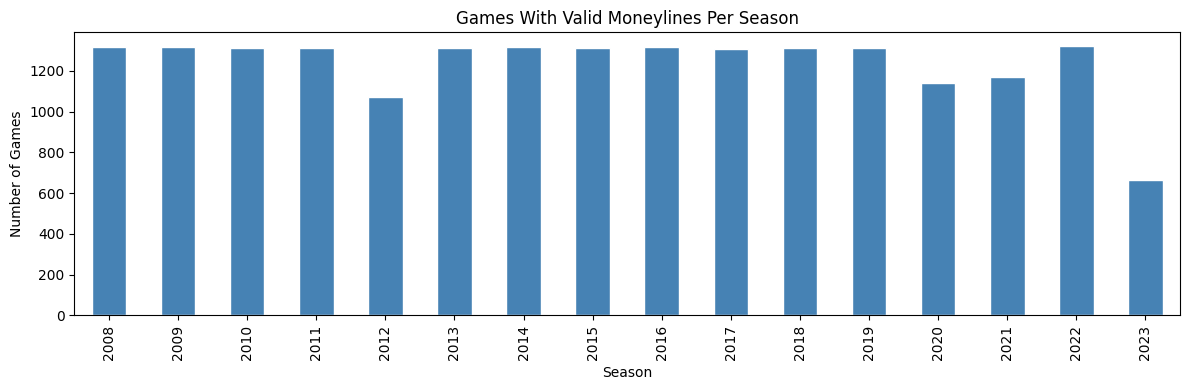

In [37]:
clean_raw['season'].value_counts().sort_index().plot(
    kind='bar', figsize=(12,4), color='steelblue', edgecolor='white'
)
plt.title('Games With Valid Moneylines Per Season')
plt.xlabel('Season')
plt.ylabel('Number of Games')
plt.tight_layout()
plt.show()